In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\HP\Downloads\Dataset .csv")
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [4]:
df[['Latitude', 'Longitude', 'City']].head()

,Latitude,Longitude,City
0,14.565443,121.027535,Makati City
1,14.553708,121.014101,Makati City
2,14.581404,121.056831,Mandaluyong City
3,14.585318,121.056475,Mandaluyong City
4,14.584450,121.057508,Mandaluyong City


In [6]:
df = df.dropna(subset=['Latitude', 'Longitude'])

In [9]:
import folium

map_center = [df['Latitude'].mean(), df['Longitude'].mean()]

restaurant_map = folium.Map(location=map_center, zoom_start=5)

for _, row in df.sample(500).iterrows(): 
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['City']
    ).add_to(restaurant_map)

restaurant_map

In [11]:
city_counts = df['City'].value_counts()

print(city_counts.head(10))

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64


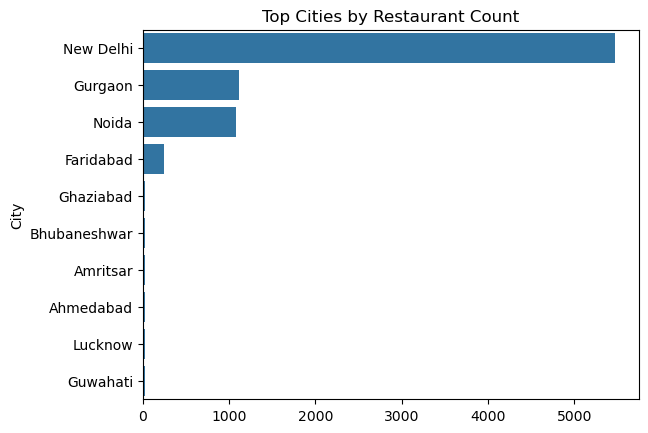

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=city_counts.head(10).values, y=city_counts.head(10).index)
plt.title("Top Cities by Restaurant Count")
plt.show()

In [14]:
avg_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

print(avg_rating.head(10))

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Tagaytay City       4.500000
Secunderabad        4.500000
Name: Aggregate rating, dtype: float64


In [15]:
price_by_city = df.groupby('City')['Price range'].mean().sort_values(ascending=False)

print(price_by_city.head(10))

City
Princeton           4.000000
Inner City          4.000000
Vineland Station    4.000000
Johannesburg        4.000000
Panchkula           4.000000
Pasay City          4.000000
Paynesville         4.000000
Sandton             3.818182
Mandaluyong City    3.750000
Pretoria            3.700000
Name: Price range, dtype: float64


In [17]:
df['Cuisines'] = df['Cuisines'].astype(str).apply(lambda x: x.split(',')[0])

cuisine_by_city = df.groupby('City')['Cuisines'].agg(lambda x: x.value_counts().index[0])

print(cuisine_by_city.head(10))

City
Abu Dhabi          Indian
Agra         North Indian
Ahmedabad    North Indian
Albany           American
Allahabad    North Indian
Amritsar     North Indian
Ankara              Kebab
Armidale         Bar Food
Athens           American
Auckland             Cafe
Name: Cuisines, dtype: object


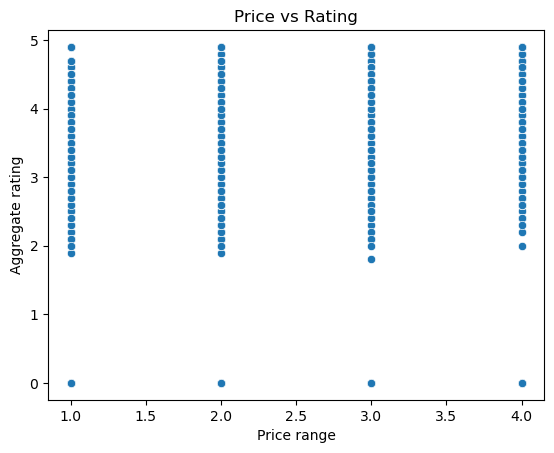

In [18]:
sns.scatterplot(x=df['Price range'], y=df['Aggregate rating'])
plt.title("Price vs Rating")
plt.show()

Technical insights:

1.Geospatial Visualization
Latitude and longitude were plotted using Folium to visualize restaurant distribution.
This provides intuitive spatial insights that tabular data cannot.

2.City-wise Aggregation
Grouping by city enabled analysis of restaurant density, average ratings, and price distribution.
Aggregation helps identify regional patterns and trends.